# HW 8 #

In [90]:
# Базовые библиотеки
import os 
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Датасеты / Трансформации
import torchvision
from torchvision import transforms

# Вспомогательные библиотеки
import json
import csv
from pathlib import Path


#Воспроизводмость
SEED = 42
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

#Все пути
ARTIFACTS_PATH = Path("./artifacts")
FIGURES_PATH = ARTIFACTS_PATH / "figures"

DATA_PATH = Path("./data")


device: cpu


## Вспомогательные функции ##

In [61]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "", filename: Path = Path("val_acc_curves.png")) -> None:
    """
    Рисует 2 графика:
      - loss: динамика изменения функции потерь для train и val выборок
      - accuracy: динамика изменения метрики accuracy для train и val выборок
    
    history ожидается вида:
    {
        "train_loss": [...], "val_loss":, [...],
        "train_acc": [...]. "val_acc": [...]
    }
    """
    # Рисуем по эпохам
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # loss-график
    axs[0].plot(epochs, history["train_loss"], label="train_loss")
    axs[0].plot(epochs, history["val_loss"], label="val_loss")
    axs[0].set_title(f"{title} - Loss")
    axs[0].legend()
    axs[0].grid(True)

    # accuracy-график
    axs[1].plot(epochs, history["train_acc"], label="train_acc")
    axs[1].plot(epochs, history["val_acc"], label="val_acc")
    axs[1].set_title(f"{title} - Accuracy")
    axs[1].legend()
    axs[1].grid(True)
    
    plt.tight_layout()
    
    # Сохранение, если указан путь
    if filename is not None:
        plt.savefig(filename)
        print(f"Plot saved to: {filename}")

    plt.show()

## Данные (CIFAR10) ##

In [62]:
# Трансформации: ToTensor и Normalize
# FashionMNIST уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

# Скачиваем датасет
train_ds = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

val_ratio = 0.2
val_size = int(len(train_ds)*val_ratio)
train_size = len(train_ds) - val_size

print(val_size, train_size)

gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_ds, [train_size, val_size], generator=gen)

10000 40000


In [63]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

#Sanity check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)


x_batch: torch.Size([64, 3, 32, 32]) torch.float32
y_batch: torch.Size([64]) torch.int64


Sanity-check показал, что всё сходится: 64 - это размер батча, 3 - количество каналов (RGB), 32х32 - размер изображения в пикселях

## Модель: MLP (nn.Module) ##

In [64]:
class MLP (nn.Module):
    def __init__ (
        self, 
        input_dim: int = 3*32*32,
        hidden_dims: tuple = (512, 256),
        num_classes: int = 10,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")
        
        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
        
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)
            


logits: torch.Size([64, 10])


## Цикл обучения: train/eval + no_grad ##

In [65]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking = True)
        y = y.to(device, non_blocking = True)

        optimizer.zero_grad(set_to_none = True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking = True)
        y = y.to(device, non_blocking = True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

## EarlyStopping ##

In [66]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score == None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        
        self.counter += 1
        return self.counter >= self.patience
    
    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


## Обучение: базовый MLP ##

In [67]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping = None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        history["val_loss"].append(va_loss)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss = {tr_loss:.4f}, acc = {tr_acc:.4f} | "
                f"val loss = {va_loss:.4f}, acc = {va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [68]:
# Для хранения результатов
all_runs = []
# Функция ошибки
criterion = nn.CrossEntropyLoss()

def run_experiment(
    exp_id,              # ID эксперимента
    model_config,        # конфигурация модели
    opt_config,          # конфигурация оптимизатора
    epochs,              # кол-во эпох обучения
    early_stopping=None  # ранняя остановка
):
    # Для чистоты сбросим зерно в начале эксперимента
    set_seed(SEED)
    
    model = MLP(**model_config).to(device)
    
    # Выбор оптимизатора
    if opt_config["type"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=opt_config["lr"],
            weight_decay=opt_config.get("weight_decay", 0)
        )
    elif opt_config["type"] == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=opt_config["lr"],
            weight_decay=opt_config.get("weight_decay", 0),
            momentum=opt_config.get("momentum", 0)
        )
    else:
        raise ValueError(f"Correct use is \"Adam\" or \"SGD\" optimizer, got {opt_config["type"]}")
    
    # История обучения
    history = fit(
        model,
        train_loader, val_loader,
        optimizer, criterion, device,
        epochs=epochs, early_stopping=early_stopping,
        verbose=True
    )
     # Лучшие метрики
    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    epochs_trained = len(history["val_acc"])
    
    # Запись в таблицу результатов
    run_record = {
        "experiment_id": exp_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_summary": f"hidden={model_config["hidden_dims"]}, dropout={model_config["dropout_p"]}, bn={model_config["use_batchnorm"]}",
        "optimizer": opt_config["type"],
        "lr": opt_config["lr"],
        "momentum": opt_config.get("momentum", 0),
        "weight_decay": opt_config.get("weight_decay", 0),
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    }
    all_runs.append(run_record)
    
    # Полный конфиг
    config = {
        "experiment_id": exp_id,
        "dataset": "CIFAR10",
        "seed": SEED,
        "model_config": model_config,
        "optimizer_config": opt_config,
    }
    if early_stopping is not None:
        config["early_stopping"] = {
            "patience": early_stopping.patience,
            "min_delta": early_stopping.min_delta
        }
    
    print(f"Experiment {exp_id} finished.")
    print(f"Epochs: {epochs_trained}")
    print(f"Best Val Acc: {best_val_acc:.4f}")
    
    return model, history, config

In [69]:
opt_cfg_E = {
    "type": "Adam",
    "lr": 1e-3,
    "weight_decay": 0
}
hidden_dims = (1024, 512, 256)

## Эксперимент 1 (E1) ##

In [98]:
set_seed(SEED)
E1_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": False
}

E1_model, hist_E1, _ = run_experiment(
    "E1",
    E1_cfg,
    opt_cfg_E,
    epochs = 20
)

epoch 01/20 | train loss = 1.7094, acc = 0.3886 | val loss = 1.5881, acc = 0.4429
epoch 02/20 | train loss = 1.4988, acc = 0.4691 | val loss = 1.5097, acc = 0.4633
epoch 03/20 | train loss = 1.3909, acc = 0.5084 | val loss = 1.4247, acc = 0.5002
epoch 04/20 | train loss = 1.3017, acc = 0.5363 | val loss = 1.4318, acc = 0.5090
epoch 05/20 | train loss = 1.2237, acc = 0.5637 | val loss = 1.4332, acc = 0.5119
epoch 06/20 | train loss = 1.1511, acc = 0.5898 | val loss = 1.4249, acc = 0.5237
epoch 07/20 | train loss = 1.0806, acc = 0.6149 | val loss = 1.4590, acc = 0.5198
epoch 08/20 | train loss = 1.0117, acc = 0.6368 | val loss = 1.4701, acc = 0.5260
epoch 09/20 | train loss = 0.9405, acc = 0.6628 | val loss = 1.5119, acc = 0.5136
epoch 10/20 | train loss = 0.8866, acc = 0.6826 | val loss = 1.5588, acc = 0.5258
epoch 11/20 | train loss = 0.8197, acc = 0.7042 | val loss = 1.6854, acc = 0.5132
epoch 12/20 | train loss = 0.7769, acc = 0.7198 | val loss = 1.6993, acc = 0.5217
epoch 13/20 | tr

Plot saved to: artifacts\figures\E1_curves.png


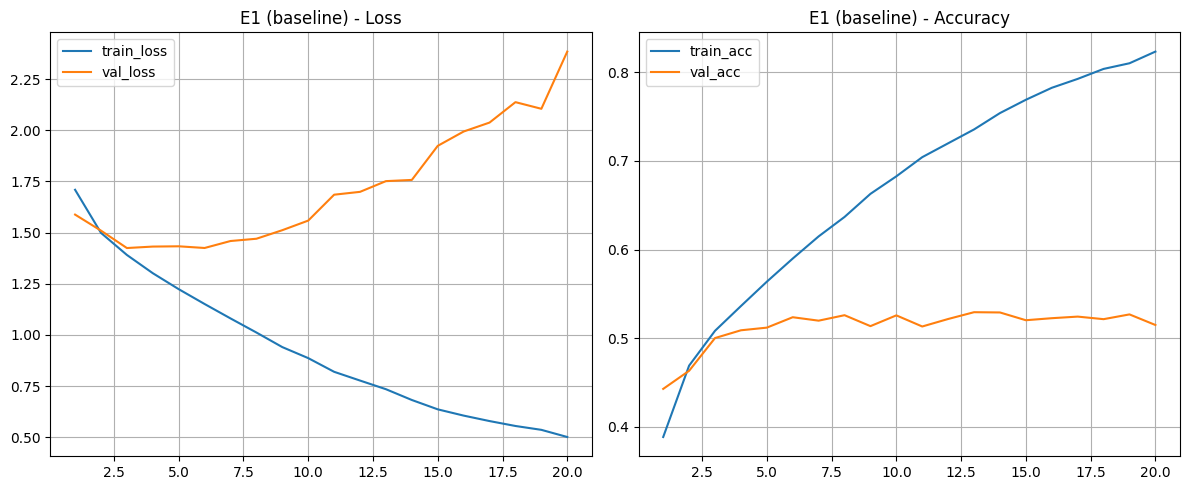

Extend Baseline test: loss=2.3375, acc=0.5150


In [99]:
plot_history(
    hist_E1,
    "E1 (baseline)",
    filename=FIGURES_PATH / "E1_curves.png"
)

test_loss_E1, test_acc_E1= evaluate(E1_model, test_loader, criterion, device)
print(f"Extend Baseline test: loss={test_loss_E1:.4f}, acc={test_acc_E1:.4f}")

## Эксперимент 2 ##

In [ ]:
set_seed(SEED)
E2_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.3,
    "use_batchnorm": False
}

E2_model, hist_E2, _ = run_experiment(
    "E2",
    E2_cfg,
    opt_cfg_E,
    epochs = 20
)


epoch 01/20 | train loss = 1.8436, acc = 0.3404 | val loss = 1.6843, acc = 0.4157
epoch 02/20 | train loss = 1.7048, acc = 0.3937 | val loss = 1.6033, acc = 0.4284
epoch 03/20 | train loss = 1.6519, acc = 0.4163 | val loss = 1.5742, acc = 0.4506
epoch 04/20 | train loss = 1.6090, acc = 0.4350 | val loss = 1.5371, acc = 0.4674
epoch 05/20 | train loss = 1.5767, acc = 0.4431 | val loss = 1.5179, acc = 0.4816
epoch 06/20 | train loss = 1.5527, acc = 0.4554 | val loss = 1.5095, acc = 0.4727
epoch 07/20 | train loss = 1.5189, acc = 0.4636 | val loss = 1.4815, acc = 0.4790
epoch 08/20 | train loss = 1.4992, acc = 0.4741 | val loss = 1.4767, acc = 0.4809
epoch 09/20 | train loss = 1.4822, acc = 0.4779 | val loss = 1.4735, acc = 0.4881
epoch 10/20 | train loss = 1.4476, acc = 0.4937 | val loss = 1.4613, acc = 0.4844
epoch 11/20 | train loss = 1.4318, acc = 0.4927 | val loss = 1.4504, acc = 0.4927
epoch 12/20 | train loss = 1.4235, acc = 0.4999 | val loss = 1.4804, acc = 0.4762
epoch 13/20 | tr

Plot saved to: artifacts\figures\E2_curves.png


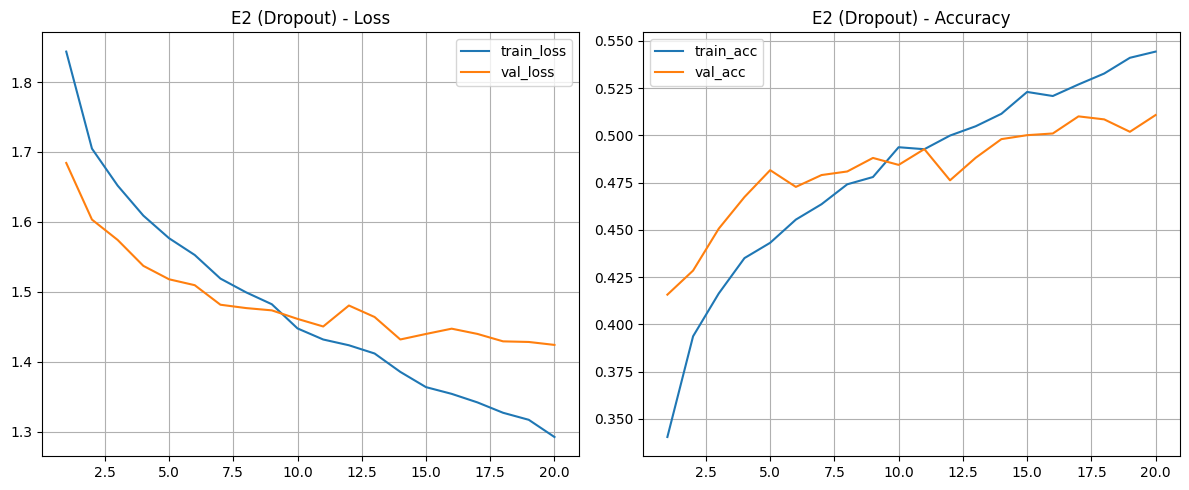

Extend Baseline test: loss=1.4286, acc=0.5072


In [ ]:
plot_history(
    hist_E2,
    "E2 (Dropout)",
    filename=FIGURES_PATH / "E2_curves.png"
)

test_loss_E2, test_acc_E2= evaluate(E2_model, test_loader, criterion, device)
print(f"Extend Baseline test: loss={test_loss_E2:.4f}, acc={test_acc_E2:.4f}")

## Эксперимент 3 ##

In [ ]:
set_seed(SEED)
E3_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": True
}

E3_model, hist_E3, _ = run_experiment(
    "E3",
    E3_cfg,
    opt_cfg_E,
    epochs = 20
)


epoch 01/20 | train loss = 1.6515, acc = 0.4037 | val loss = 1.4803, acc = 0.4733
epoch 02/20 | train loss = 1.4306, acc = 0.4903 | val loss = 1.4142, acc = 0.4884
epoch 03/20 | train loss = 1.3155, acc = 0.5308 | val loss = 1.3417, acc = 0.5209
epoch 04/20 | train loss = 1.2231, acc = 0.5604 | val loss = 1.3209, acc = 0.5394
epoch 05/20 | train loss = 1.1417, acc = 0.5916 | val loss = 1.2745, acc = 0.5475
epoch 06/20 | train loss = 1.0592, acc = 0.6201 | val loss = 1.3069, acc = 0.5500
epoch 07/20 | train loss = 0.9856, acc = 0.6514 | val loss = 1.3293, acc = 0.5476
epoch 08/20 | train loss = 0.9049, acc = 0.6761 | val loss = 1.3267, acc = 0.5504
epoch 09/20 | train loss = 0.8269, acc = 0.7020 | val loss = 1.3500, acc = 0.5557
epoch 10/20 | train loss = 0.7484, acc = 0.7312 | val loss = 1.3833, acc = 0.5613
epoch 11/20 | train loss = 0.6680, acc = 0.7608 | val loss = 1.4411, acc = 0.5493
epoch 12/20 | train loss = 0.5974, acc = 0.7860 | val loss = 1.5437, acc = 0.5453
epoch 13/20 | tr

Plot saved to: artifacts\figures\E3_curves.png


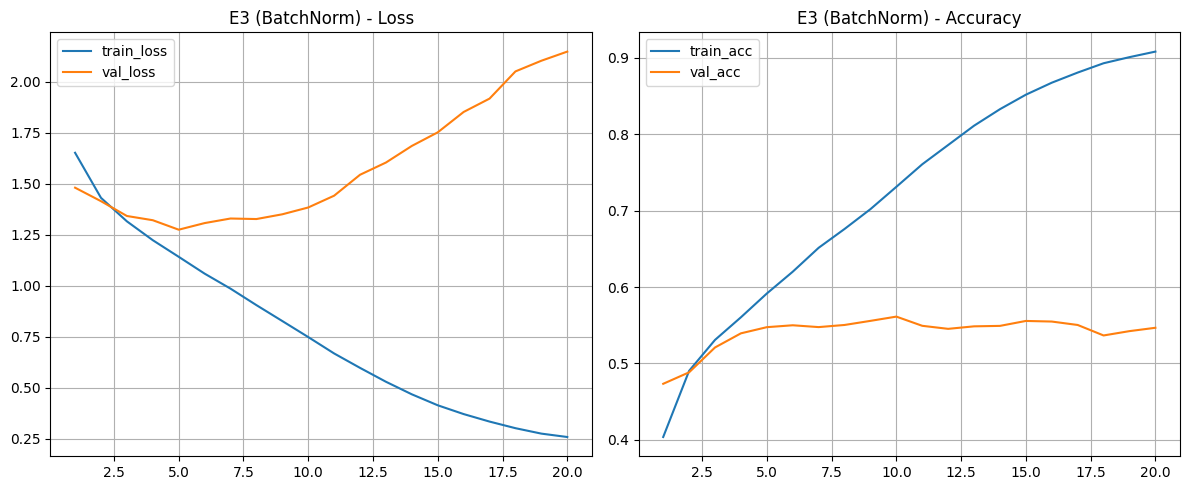

Dropout Model test: loss=2.1257, acc=0.5388


In [72]:
plot_history(
    hist_E3,
    "E3 (BatchNorm)",
    filename=FIGURES_PATH / "E3_curves.png"
)

test_loss_E3, test_acc_E3 = evaluate(E3_model, test_loader, criterion, device)
print(f"Dropout Model test: loss={test_loss_E3:.4f}, acc={test_acc_E3:.4f}")

## Эксперимент 4 (E4) ##

In [76]:
set_seed(SEED)
E4_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": True
}
es = EarlyStopping(patience=5, min_delta=5e-5)

E4_model, hist_E4, config_e4 = run_experiment(
    "E4",
    E4_cfg,
    opt_cfg_E,
    epochs = 50,
    early_stopping=es
)


epoch 01/50 | train loss = 1.6515, acc = 0.4037 | val loss = 1.4803, acc = 0.4733
epoch 02/50 | train loss = 1.4306, acc = 0.4903 | val loss = 1.4142, acc = 0.4884
epoch 03/50 | train loss = 1.3155, acc = 0.5308 | val loss = 1.3417, acc = 0.5209
epoch 04/50 | train loss = 1.2231, acc = 0.5604 | val loss = 1.3209, acc = 0.5394
epoch 05/50 | train loss = 1.1417, acc = 0.5916 | val loss = 1.2745, acc = 0.5475
epoch 06/50 | train loss = 1.0592, acc = 0.6201 | val loss = 1.3069, acc = 0.5500
epoch 07/50 | train loss = 0.9856, acc = 0.6514 | val loss = 1.3293, acc = 0.5476
epoch 08/50 | train loss = 0.9049, acc = 0.6761 | val loss = 1.3267, acc = 0.5504
epoch 09/50 | train loss = 0.8269, acc = 0.7020 | val loss = 1.3500, acc = 0.5557
epoch 10/50 | train loss = 0.7484, acc = 0.7312 | val loss = 1.3833, acc = 0.5613
epoch 11/50 | train loss = 0.6680, acc = 0.7608 | val loss = 1.4411, acc = 0.5493
epoch 12/50 | train loss = 0.5974, acc = 0.7860 | val loss = 1.5437, acc = 0.5453
epoch 13/50 | tr

Plot saved to: artifacts\figures\curves_best.png


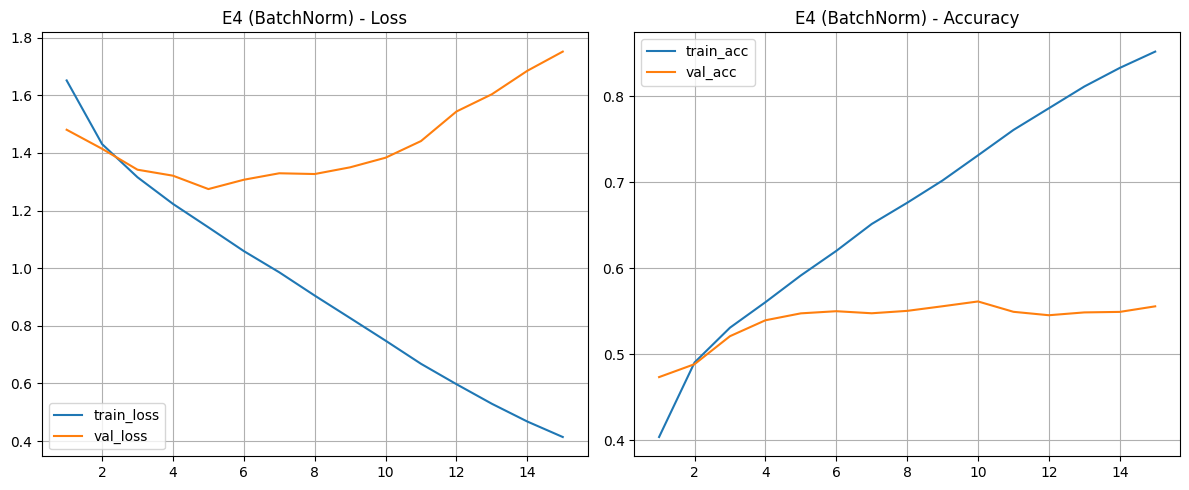

Dropout Model test: loss=1.3878, acc=0.5562


In [93]:
plot_history(
    hist_E4,
    "E4 (BatchNorm)",
    filename=FIGURES_PATH / "curves_best.png"
)

test_loss_E4, test_acc_E4 = evaluate(E4_model, test_loader, criterion, device)
print(f"Dropout Model test: loss={test_loss_E4:.4f}, acc={test_acc_E4:.4f}")

In [77]:
# Сохранение лучшей модели (E4)
torch.save(E4_model.state_dict(), ARTIFACTS_PATH / "best_model.pt")
print("Saved best_model.pt")

Saved best_model.pt


In [78]:
# Сохранение конфигурации лучшей модели (используем возвращенный config_e4)
with open(ARTIFACTS_PATH / "best_config.json", "w") as f:
    json.dump(config_e4, f, indent=2)
print("Saved best_config.json")

Saved best_config.json


# HW 9 #

## O1 ##

In [85]:
set_seed(SEED)
opt_cfg_O1 = {
    "type": "Adam",
    "lr": 1e-1,
    "weight_decay": 0
}

O_cfg = {
    "hidden_dims": hidden_dims,
    "dropout_p": 0.0,
    "use_batchnorm": False
}

O1_model, hist_O1, config_O1 = run_experiment(
    "O1",
    O_cfg,
    opt_cfg_O1,
    epochs = 8,
)

epoch 01/8 | train loss = 316.0108, acc = 0.1003 | val loss = 2.3070, acc = 0.1000
epoch 02/8 | train loss = 2.3113, acc = 0.1031 | val loss = 2.3109, acc = 0.0993
epoch 03/8 | train loss = 2.3112, acc = 0.0999 | val loss = 2.3113, acc = 0.0965
epoch 04/8 | train loss = 2.3102, acc = 0.1000 | val loss = 2.3036, acc = 0.1000
epoch 05/8 | train loss = 2.3120, acc = 0.1010 | val loss = 2.3159, acc = 0.0964
epoch 06/8 | train loss = 2.3125, acc = 0.0981 | val loss = 2.3069, acc = 0.0964
epoch 07/8 | train loss = 2.3110, acc = 0.0991 | val loss = 2.3051, acc = 0.1007
epoch 08/8 | train loss = 2.3121, acc = 0.0993 | val loss = 2.3061, acc = 0.0964
Experiment O1 finished.
Epochs: 8
Best Val Acc: 0.1007


## O2 ##

In [ ]:
opt_cfg_O2 = {
    "type": "Adam",
    "lr": 1e-5,
    "weight_decay": 0
}

O2_model, hist_O2, _ = run_experiment(
    "O2",
    O_cfg,
    opt_cfg_O2,
    epochs=8
)

epoch 01/8 | train loss = 1.9891, acc = 0.3079 | val loss = 1.7833, acc = 0.3747
epoch 02/8 | train loss = 1.7092, acc = 0.4001 | val loss = 1.6573, acc = 0.4132
epoch 03/8 | train loss = 1.6149, acc = 0.4358 | val loss = 1.5964, acc = 0.4357
epoch 04/8 | train loss = 1.5550, acc = 0.4555 | val loss = 1.5566, acc = 0.4507
epoch 05/8 | train loss = 1.5090, acc = 0.4732 | val loss = 1.5273, acc = 0.4654
epoch 06/8 | train loss = 1.4698, acc = 0.4863 | val loss = 1.5037, acc = 0.4762
epoch 07/8 | train loss = 1.4341, acc = 0.4988 | val loss = 1.4766, acc = 0.4825
epoch 08/8 | train loss = 1.4036, acc = 0.5122 | val loss = 1.4566, acc = 0.4904
Experiment O2 finished.
Epochs: 8
Best Val Acc: 0.4904


Saved curves_lr_extremes.png


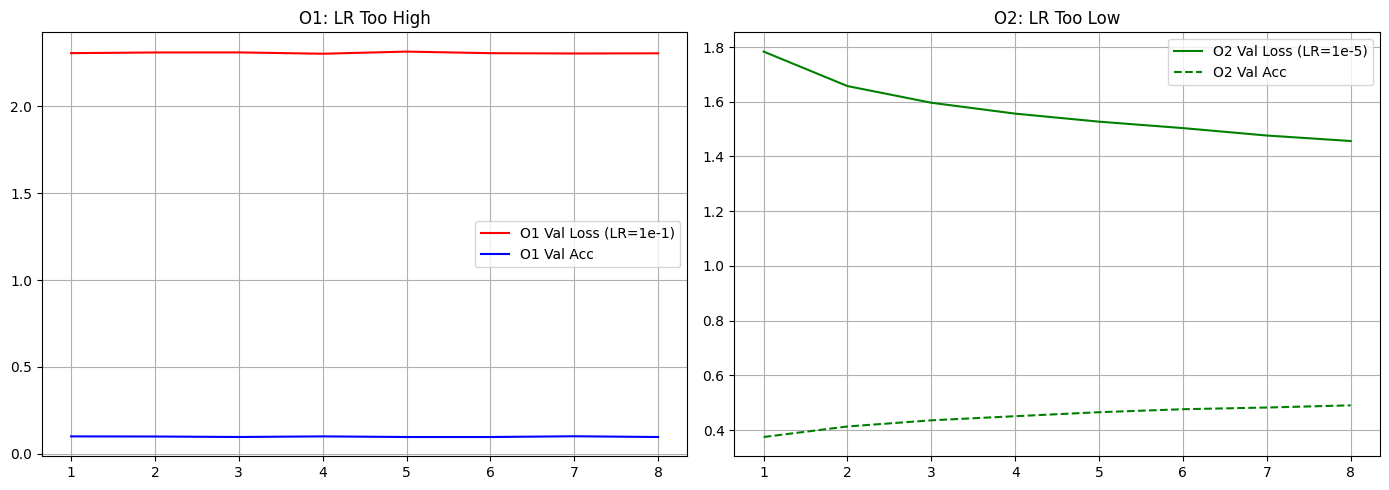

In [92]:
# График сравнения LR (O1 и O2)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# O1 Plot
epochs_o1 = np.arange(1, len(hist_O1["train_loss"]) + 1)
axs[0].plot(epochs_o1, hist_O1["val_loss"], label="O1 Val Loss (LR=1e-1)", color="red")
axs[0].plot(epochs_o1, hist_O1["val_acc"], label="O1 Val Acc", color="blue")
axs[0].set_title("O1: LR Too High")
axs[0].legend()
axs[0].grid(True)

# O2 Plot
epochs_o2 = np.arange(1, len(hist_O2["train_loss"]) + 1)
axs[1].plot(epochs_o2, hist_O2["val_loss"], label="O2 Val Loss (LR=1e-5)", color="green")
axs[1].plot(epochs_o2, hist_O2["val_acc"], label="O2 Val Acc", linestyle="--", color="green")
axs[1].set_title("O2: LR Too Low")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.savefig(FIGURES_PATH / "curves_lr_extremes.png")
print("Saved curves_lr_extremes.png")

plt.show()

## O3 ##

In [87]:
opt_cfg_O3 = {
    "type": "SGD",
    "lr": 1e-3,
    "momentum": 0.9,
    "weight_decay": 1e-4
}

O3_model, hist_O3, _ = run_experiment(
    "O3",
    O_cfg,
    opt_cfg_O3,
    epochs = 15
)

epoch 01/15 | train loss = 2.1021, acc = 0.2552 | val loss = 1.8886, acc = 0.3349
epoch 02/15 | train loss = 1.7778, acc = 0.3710 | val loss = 1.6928, acc = 0.3997
epoch 03/15 | train loss = 1.6269, acc = 0.4246 | val loss = 1.5875, acc = 0.4311
epoch 04/15 | train loss = 1.5273, acc = 0.4610 | val loss = 1.5146, acc = 0.4676
epoch 05/15 | train loss = 1.4459, acc = 0.4904 | val loss = 1.4640, acc = 0.4849
epoch 06/15 | train loss = 1.3740, acc = 0.5141 | val loss = 1.4268, acc = 0.5018
epoch 07/15 | train loss = 1.3101, acc = 0.5397 | val loss = 1.3881, acc = 0.5173
epoch 08/15 | train loss = 1.2512, acc = 0.5615 | val loss = 1.3748, acc = 0.5220
epoch 09/15 | train loss = 1.1944, acc = 0.5787 | val loss = 1.3569, acc = 0.5247
epoch 10/15 | train loss = 1.1409, acc = 0.5995 | val loss = 1.3600, acc = 0.5260
epoch 11/15 | train loss = 1.0834, acc = 0.6200 | val loss = 1.3648, acc = 0.5280
epoch 12/15 | train loss = 1.0321, acc = 0.6383 | val loss = 1.3575, acc = 0.5331
epoch 13/15 | tr

Plot saved to: artifacts\figures\O3_curves .png


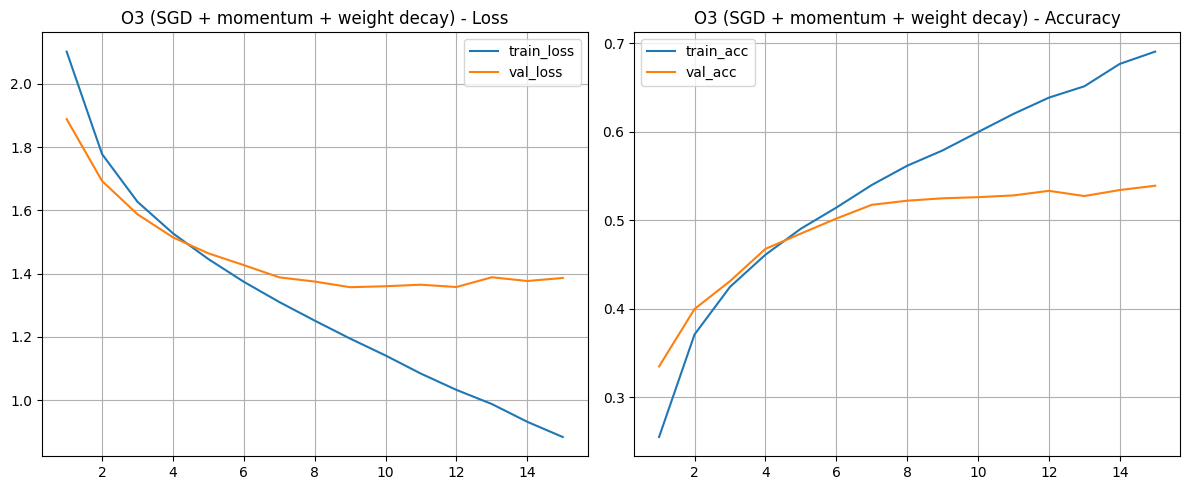

In [88]:
plot_history(
    hist_O3,
    "O3 (SGD + momentum + weight decay)",
    filename=FIGURES_PATH / "O3_curves .png"
)

## Результаты ##

In [91]:
csv_path = ARTIFACTS_PATH / "runs.csv"
if all_runs:
    keys = all_runs[0].keys()
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=keys)
        writer.writeheader()
        writer.writerows(all_runs)
    print(f"Saved runs.csv to {csv_path}")
else:
    print("No runs to save")

Saved runs.csv to artifacts\runs.csv
